# Superposition, Entanglement and Interference in Qiskit
These notebooks have been adapted from Q# Katas in Quantum Computing


In [1]:
from qiskit import QuantumCircuit
# from qiskit_aer import AerSimulator
from qiskit.visualization import circuit_drawer, plot_histogram
from qiskit.quantum_info import Statevector

### <a name="superposition-of-basis-vectors-with-phase-flip"></a>Task 1: Superposition of basis vectors with phase flip.

**Initial state:** Two qubits in the $|00\rangle$ state.

**Goal:** Change the state of the qubits to $\frac{1}{2}\big(|00\rangle+|01\rangle+|10\rangle-|11\rangle \big)$.

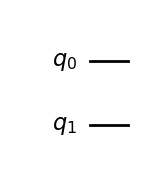

In [10]:
qc = QuantumCircuit(2)

qc.draw(output='mpl', style="clifford")

In [11]:
print(qc)

     
q_0: 
     
q_1: 
     


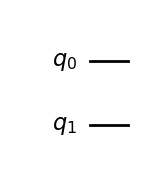

In [12]:
circuit_drawer(qc, output='mpl', plot_barriers=False)

In [13]:
state = Statevector.from_instruction(qc)

print ("State:", state)

State: Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))


## <a name="superposition-of-basis-vectors-with-phases"></a>Task 2: Superposition of basis vectors with phases.

**Initial state:** Two qubits in the $|00\rangle$ state.

**Goal:** Change the state of the qubits to $\frac{1}{2} \big(|00\rangle + i|01\rangle - |10\rangle - i|11\rangle\big)$.

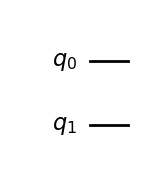

In [15]:
qc = QuantumCircuit(2)

qc.draw(output='mpl', style="clifford")

Make sure the state is indeed  $\frac{1}{2} \big(|00\rangle + i|01\rangle - |10\rangle - i|11\rangle\big)$.

In [16]:
Statevector(qc)

Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))


## <a name="greenberger-horne-zeilinger"></a> Task 3: Greenberger-Horne-Zeilinger state.

**Input:**

1. `qc`: A QuantumCircuit with $N$ ($N \ge 1$) qubits in the $|0 \dots 0\rangle$ state.
2. An integer `n`: Number of qubits
    
**Goal:**  Change the state of the qubits to the GHZ state $\frac{1}{\sqrt{2}} \big (|0\dots0\rangle + |1\dots1\rangle\big)$.

In [21]:
def prepareGHZ(qc, n):
    qc.id(0)
    for i in range(1, n):
        qc.id(i)

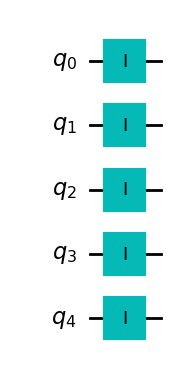

In [22]:
qc = QuantumCircuit(5)
prepareGHZ(qc, 5)
qc.draw(output='mpl', style="clifford")

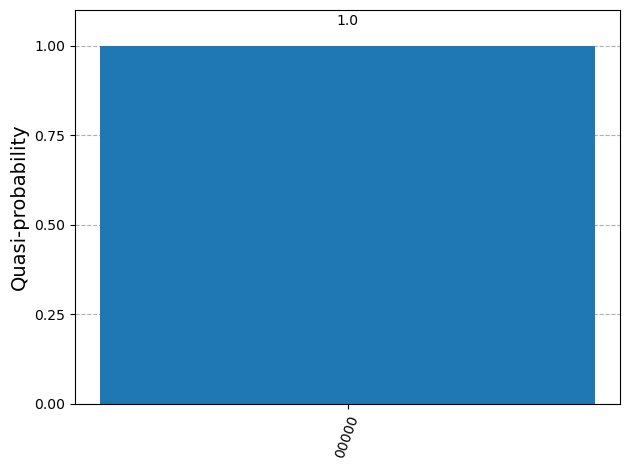

In [23]:
state = Statevector.from_instruction(qc)


probs = state.probabilities_dict()
plot_histogram(probs)

## <a name="superposition-of-all-basis-vectors"></a>  Task 4. Superposition of all basis vectors.

**Input:**
1. `qc`: A QuantumCircuit with $N$ ($N \ge 1$) qubits in the $|0 \dots 0\rangle$ state.
2. `n`: An integer representing the number of qubits

**Goal:**  Change the state of the qubits to an equal superposition of all basis vectors $\frac{1}{\sqrt{2^N}} \big (|0 \dots 0\rangle + \dots + |1 \dots 1\rangle\big)$.

> For example, for $N = 2$ the final state should be  $\frac{1}{2} \big (|00\rangle + |01\rangle + |10\rangle + |11\rangle\big)$.

In [24]:
def superpose(qc, n):
    for i in range(n):
        qc.id(i)

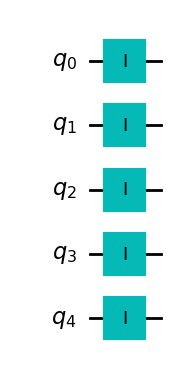

In [25]:
qc = QuantumCircuit(5)
superpose(qc, 5)
qc.draw(output='mpl', style="clifford")

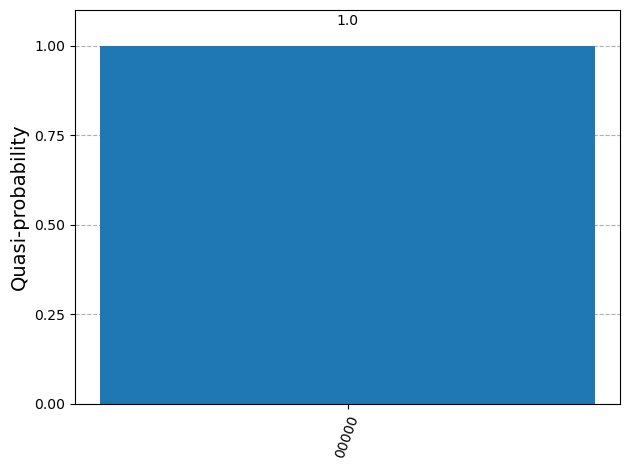

In [26]:

state = Statevector.from_instruction(qc)
probs = state.probabilities_dict()

plot_histogram(probs)

## <a name="superposition-of-all-even-or-all-odd-numbers"></a>Task 5: Funky Superposition: Superposition of all even or all odd numbers.

**Inputs:**

1. `qc`: A QuantumCircuit with $N$ ($N \ge 1$) qubits in the $|0 \dots 0\rangle$ state.
2. `n`: An integer representing the number of qubits
2. A boolean `isEven`.

**Goal:**  Prepare a superposition of all *even* numbers if `isEven` is `true`, or of all *odd* numbers if `isEven` is `false`.  
A basis state encodes an integer number using [big-endian](https://en.wikipedia.org/wiki/Endianness) binary notation: state $|01\rangle$ corresponds to the integer $1$, and state $|10 \rangle$ - to the integer $2$.  

> For example, for $N = 2$ and `isEven = false` you need to prepare superposition $\frac{1}{\sqrt{2}} \big (|01\rangle + |11\rangle\big )$,  
and for $N = 2$ and `isEven = true` - superposition $\frac{1}{\sqrt{2}} \big (|00\rangle + |10\rangle\big )$.
</details>

In [27]:
def funkySuperposition(qc, n, isEven):
    for i in range(0, n-1):
        qc.id(i)

    if not isEven:
        qc.id(n-1)

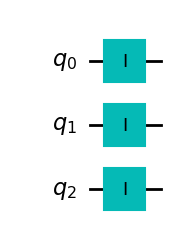

In [28]:
qc = QuantumCircuit(3)
funkySuperposition(qc, 3, False)
qc.draw(output='mpl', style="clifford")

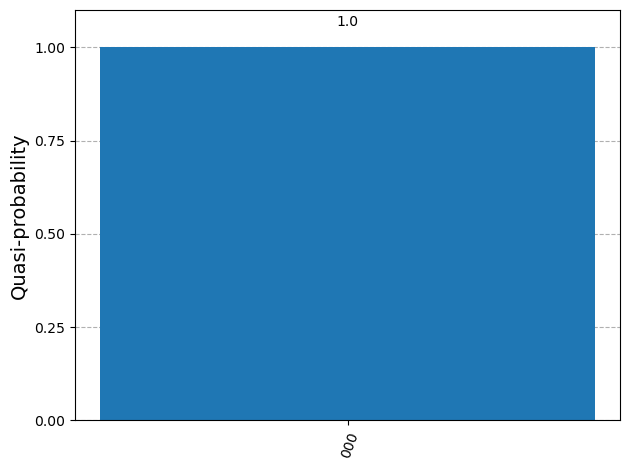

In [29]:
state = Statevector.from_instruction(qc)

probs = state.probabilities_dict()

plot_histogram(probs)


### <a name="superposition-of-zero-and-given-bit-string"></a>Task 6: Groovy GHZ: Superposition of $|0 \dots 0\rangle$ and the given bit string.

**Inputs:**

1. `qc`: A QuantumCircuit with $N$ ($N \ge 1$) qubits in the $|0 \dots 0\rangle$ state.
2. `n`: An integer representing the number of qubits
2. A bit string of length $N$ represented as `Bool` list. Bit values `false` and `true` correspond to $|0\rangle$ and $|1\rangle$ states. **You are guaranteed that the first bit of the bit string is `true`**.

**Goal:**  Change the state of the qubits to an equal superposition of $|0 \dots 0\rangle$ and the basis state given by the bit string.

> For example, for the bit string `[true, false, true,  true]` the state required is $\frac{1}{2}\big(|0000\rangle + |1011\rangle\big)$.

In [30]:
def groovyGHZ(qc, n, bitstring):
    qc.id(0)
    for i in range(1, n):
        if bitstring[i]:
            qc.id(0)

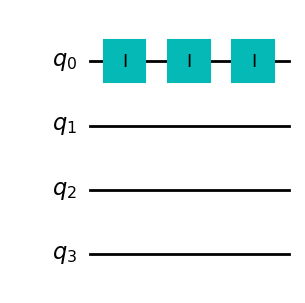

In [31]:
qc = QuantumCircuit(4)
bitstring = [True, False, True, True]
groovyGHZ(qc, 4, bitstring)
qc.draw(output='mpl', style="clifford")

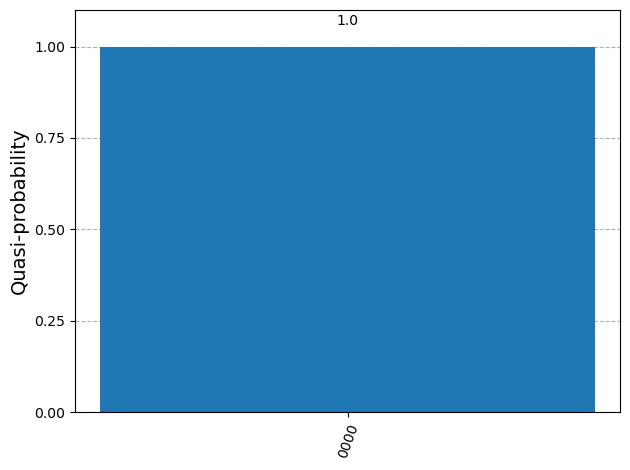

In [32]:
state = Statevector.from_instruction(qc)
probs = state.probabilities_dict()
plot_histogram(probs)